In [1]:
import os
import yaml
import pymongo
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.notebook import tqdm
from scipy.signal import butter, lfilter
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

# Φόρτωση ρυθμίσεων και Σύνδεση στη MongoDB
config_path = os.path.join(os.getcwd(), "config.yml")
with open(config_path, 'r', encoding='utf-8') as file:
    config = yaml.load(file, Loader=yaml.FullLoader)

client = pymongo.MongoClient(config["client"])
db = client[config["db"]]
coll = db[config["col"]]

# Φόρτωση Δεδομένων
cursor = coll.find({})
df_list = []

for doc in tqdm(cursor, desc="Φόρτωση Δεδομένων"):
    df = pd.DataFrame(doc['data'])
    df['gesture_id'] = doc['gesture_id']
    df['user'] = doc['user'].lower() # Μετατροπή σε πεζά 
    df_list.append(df)

print(f"Φορτώθηκαν {len(df_list)} αρχεία/καταγραφές.")

sensor_cols = ['acc_x', 'acc_y', 'acc_z', 'gyr_x', 'gyr_y', 'gyr_z']

Φόρτωση Δεδομένων: 0it [00:00, ?it/s]

Φορτώθηκαν 15 αρχεία/καταγραφές.


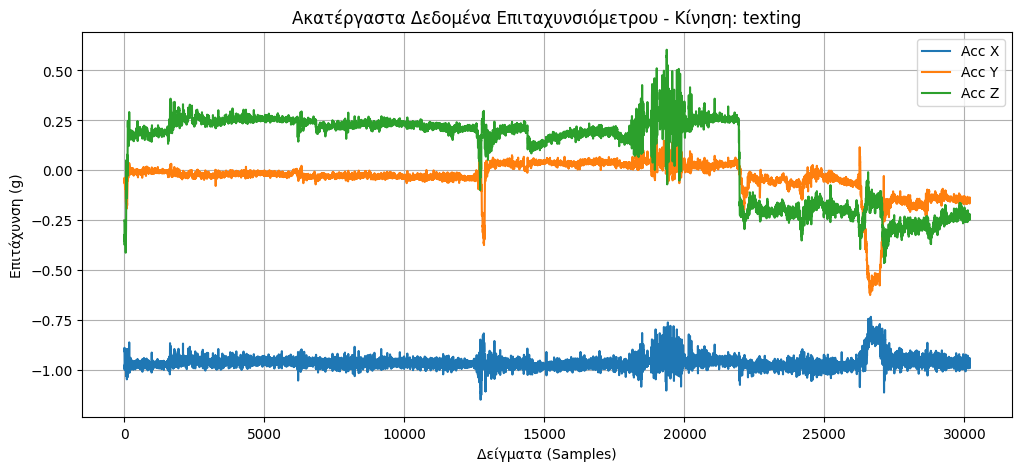

In [2]:
# Επιλέγουμε ένα DataFrame της λίστας για οπτικοποίηση
sample_df = df_list[13]
label = sample_df['gesture_id'].iloc[13]

plt.figure(figsize=(12, 5))
plt.plot(sample_df['acc_x'], label='Acc X')
plt.plot(sample_df['acc_y'], label='Acc Y')
plt.plot(sample_df['acc_z'], label='Acc Z')
plt.title(f"Ακατέργαστα Δεδομένα Επιταχυνσιόμετρου - Κίνηση: {label}")
plt.xlabel("Δείγματα (Samples)")
plt.ylabel("Επιτάχυνση (g)")
plt.legend()
plt.grid(True)
plt.show()


 Έλεγχος για Κενές Τιμές (Missing Values)
Δεν βρέθηκαν κενές τιμές στα δεδομένα μας.


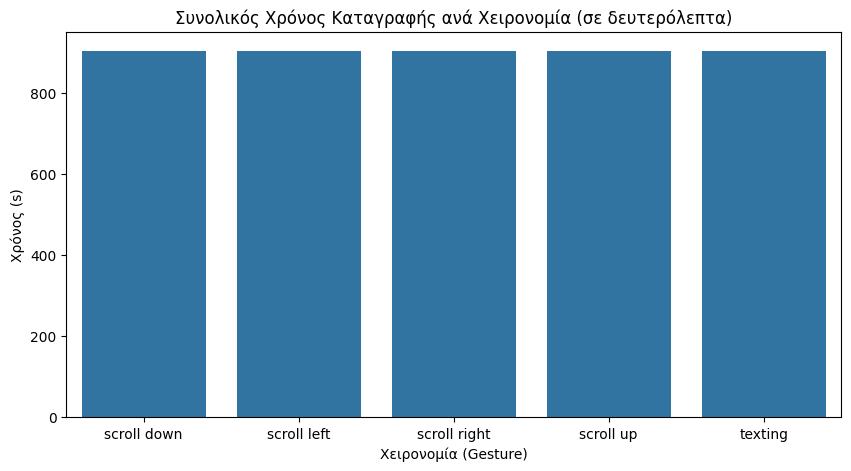

In [3]:
print("\n Έλεγχος για Κενές Τιμές (Missing Values)")
missing_found = False
for i, df in enumerate(df_list):
    if df.isnull().sum().sum() > 0:
        print(f"Βρέθηκαν κενές τιμές στο αρχείο {i}.")
        df.dropna(inplace=True)
        missing_found = True
if not missing_found:
    print("Δεν βρέθηκαν κενές τιμές στα δεδομένα μας.")

# Barplot 1: Συνολικός χρόνος ανά κλάση (Η συχνότητα είναι 100Hz, άρα 100 samples = 1 δευτερόλεπτο)
time_per_class = {}
for df in df_list:
    label = df['gesture_id'].iloc[0]
    # Διάρκεια σε δευτερόλεπτα
    duration = len(df) / 100.0 
    time_per_class[label] = time_per_class.get(label, 0) + duration

plt.figure(figsize=(10, 5))
sns.barplot(x=list(time_per_class.keys()), y=list(time_per_class.values()), )
plt.title("Συνολικός Χρόνος Καταγραφής ανά Χειρονομία (σε δευτερόλεπτα)")
plt.xlabel("Χειρονομία (Gesture)")
plt.ylabel("Χρόνος (s)")
plt.show()

 Time vs Amplitude Plot (Έλεγχος Ορθότητας Συλλογής)


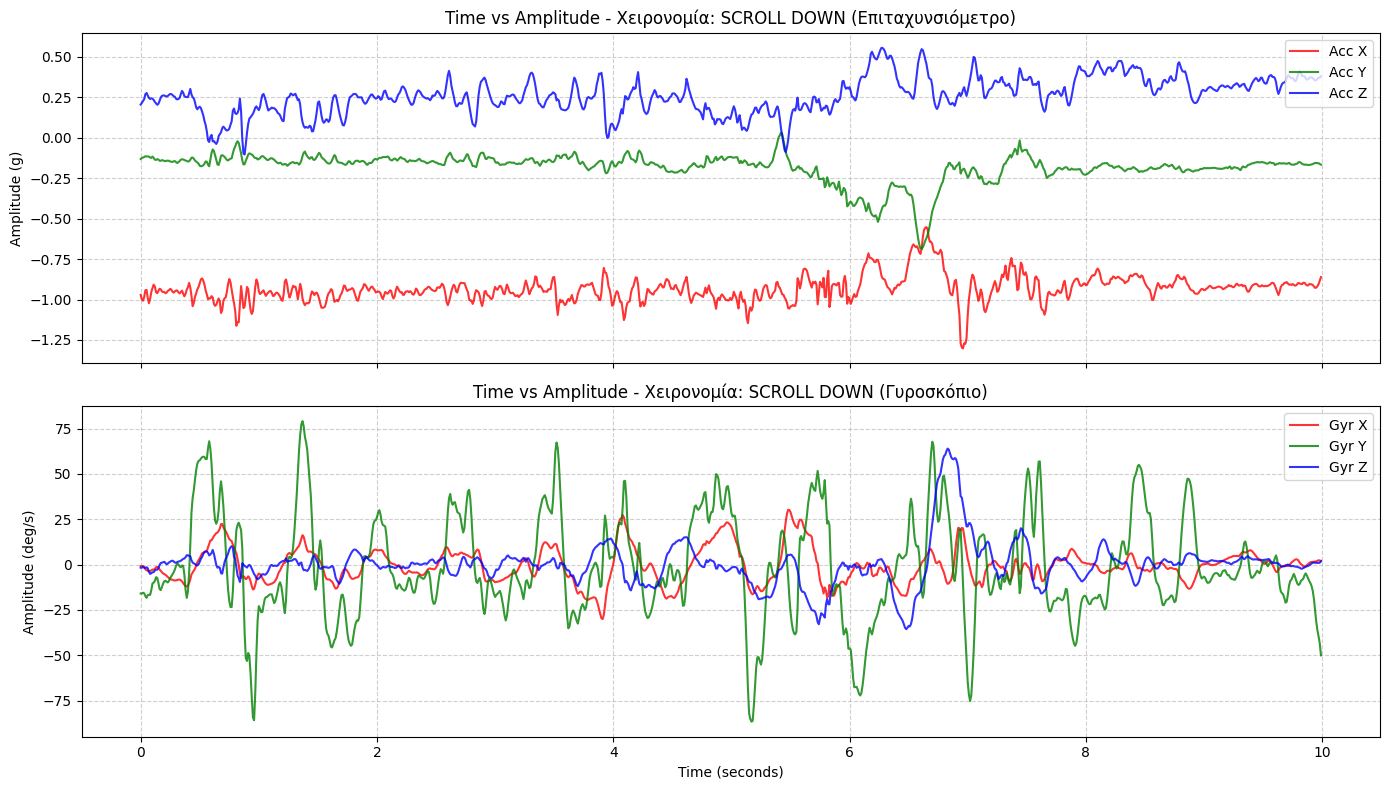

In [4]:
import numpy as np
import matplotlib.pyplot as plt

print(" Time vs Amplitude Plot (Έλεγχος Ορθότητας Συλλογής)")

sample_df = df_list[0]
gesture_name = sample_df['gesture_id'].iloc[0]

#  Καθορισμός Ανάλυσης (Resolution)
# κρατάμε μόνο τα πρώτα 10 δευτερόλεπτα. Στα 100Hz, αυτό σημαίνει 10 * 100 = 1000 δείγματα.
duration_sec = 10
samples_to_plot = int(duration_sec * 100)
plot_df = sample_df.iloc[:samples_to_plot]

#  Δημιουργία του πραγματικού άξονα χρόνου (σε δευτερόλεπτα)
# Διαιρούμε το index με το 100 (συχνότητα δειγματοληψίας)
time_axis = np.arange(len(plot_df)) / 100.0

# Δημιουργία Γραφήματος με 2 Subplots (Ένα για Επιταχυνσιόμετρο, ένα για Γυροσκόπιο)
# Χρησιμοποιούμε 2 γραφήματα γιατί το πλάτος (amplitude) τους έχει διαφορετικές μονάδες μέτρησης (g vs deg/s)
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

# Γράφημα 1: Επιταχυνσιόμετρο (Accelerometer)
ax1.plot(time_axis, plot_df['acc_x'], label='Acc X', color='red', alpha=0.8)
ax1.plot(time_axis, plot_df['acc_y'], label='Acc Y', color='green', alpha=0.8)
ax1.plot(time_axis, plot_df['acc_z'], label='Acc Z', color='blue', alpha=0.8)
ax1.set_title(f"Time vs Amplitude - Χειρονομία: {gesture_name.upper()} (Επιταχυνσιόμετρο)")
ax1.set_ylabel("Amplitude (g)")
ax1.legend(loc='upper right')
ax1.grid(True, linestyle='--', alpha=0.6)

# Γράφημα 2: Γυροσκόπιο (Gyroscope)
ax2.plot(time_axis, plot_df['gyr_x'], label='Gyr X', color='red', alpha=0.8)
ax2.plot(time_axis, plot_df['gyr_y'], label='Gyr Y', color='green', alpha=0.8)
ax2.plot(time_axis, plot_df['gyr_z'], label='Gyr Z', color='blue', alpha=0.8)
ax2.set_title(f"Time vs Amplitude - Χειρονομία: {gesture_name.upper()} (Γυροσκόπιο)")
ax2.set_ylabel("Amplitude (deg/s)")
ax2.set_xlabel("Time (seconds)")
ax2.legend(loc='upper right')
ax2.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

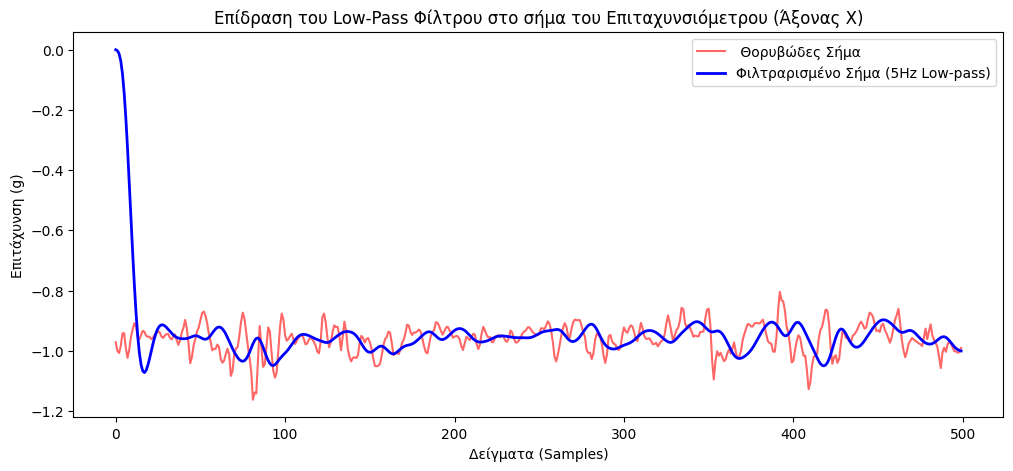

In [5]:
def butter_lowpass_filter(data, cutoff, fs, order=4):
    nyq = 0.5 * fs
    normal_cutoff = cutoff / nyq
    b, a = butter(order, normal_cutoff, btype='low', analog=False)
    return lfilter(b, a, data)

# Πριν το φίλτρο 
sample_df = df_list[0].copy()
raw_signal = sample_df['acc_x'][:500] # Πρώτα 500 samples (5 δευτερόλεπτα)

# Εφαρμόζουμε το φίλτρο σε ΟΛΑ τα DataFrames της λίστας
fs = 100.0
cutoff = 5.0
for df in df_list:
    for col in sensor_cols:
        df[col] = butter_lowpass_filter(df[col], cutoff, fs)

filtered_signal = df_list[0]['acc_x'][:500]

# Γράφημα: Επίδραση του Φίλτρου
plt.figure(figsize=(12, 5))
plt.plot(raw_signal, label=' Θορυβώδες Σήμα ', alpha=0.6, color='red')
plt.plot(filtered_signal, label='Φιλτραρισμένο Σήμα (5Hz Low-pass)', color='blue', linewidth=2)
plt.title("Επίδραση του Low-Pass Φίλτρου στο σήμα του Επιταχυνσιόμετρου (Άξονας X)")
plt.xlabel("Δείγματα (Samples)")
plt.ylabel("Επιτάχυνση (g)")
plt.legend()
plt.show()


Συνολικά Παράθυρα: 4501
Τιμές ανά Παράθυρο (1200 = 200 samples x 6 sensors): 1200


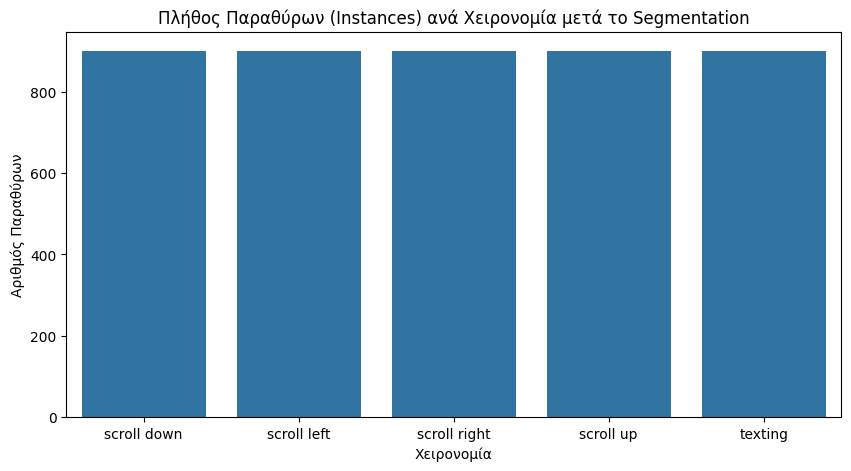

In [6]:
window_size = 200 # 2 δευτερόλεπτα στα 100Hz
overlap = 100     # 50% επικάλυψη

X_list = []
y_list = []
user_list = [] # διαχωρισμό Train/Test

for df in df_list:
    gesture = df['gesture_id'].iloc[0]
    user = df['user'].iloc[0]
    
    for start in range(0, len(df) - window_size, overlap):
        window = df[sensor_cols].iloc[start:start+window_size]
        
        #  Flattening 
        flattened_window = window.values.flatten()
        
        X_list.append(flattened_window)
        y_list.append(gesture)
        user_list.append(user)

X = np.array(X_list)
y = np.array(y_list)
users = np.array(user_list)

print(f"\nΣυνολικά Παράθυρα: {X.shape[0]}")
print(f"Τιμές ανά Παράθυρο (1200 = 200 samples x 6 sensors): {X.shape[1]}")

# Barplot 2: Πλήθος παραθύρων ανά κλάση μετά την τμηματοποίηση
plt.figure(figsize=(10, 5))
sns.countplot(x=y,)
plt.title("Πλήθος Παραθύρων (Instances) ανά Χειρονομία μετά το Segmentation")
plt.xlabel("Χειρονομία")
plt.ylabel("Αριθμός Παραθύρων")
plt.show()

In [7]:
train_users = ['mitsos', 'alexis']
test_users = ['mpakas']

# Βρίσκουμε τις θέσεις (indices) για τα αντίστοιχα σετ
train_idx = np.isin(users, train_users)
test_idx = np.isin(users, test_users)

X_train = X[train_idx]
y_train = y[train_idx]
X_test = X[test_idx]
y_test = y[test_idx]

print(f"\nΜέγεθος Σετ Εκπαίδευσης (Train - {train_users}): {X_train.shape[0]} παράθυρα")
print(f"Μέγεθος Σετ Ελέγχου (Test - {test_users}): {X_test.shape[0]} παράθυρα")

# Scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


Μέγεθος Σετ Εκπαίδευσης (Train - ['mitsos', 'alexis']): 3000 παράθυρα
Μέγεθος Σετ Ελέγχου (Test - ['mpakas']): 1501 παράθυρα



 Εκπαίδευση Απλού Μοντέλου SVM 
              precision    recall  f1-score   support

 scroll down       0.16      0.20      0.18       300
 scroll left       0.00      0.00      0.00       300
scroll right       0.00      0.00      0.00       300
   scroll up       0.26      0.42      0.32       301
     texting       0.44      0.83      0.57       300

    accuracy                           0.29      1501
   macro avg       0.17      0.29      0.21      1501
weighted avg       0.17      0.29      0.21      1501



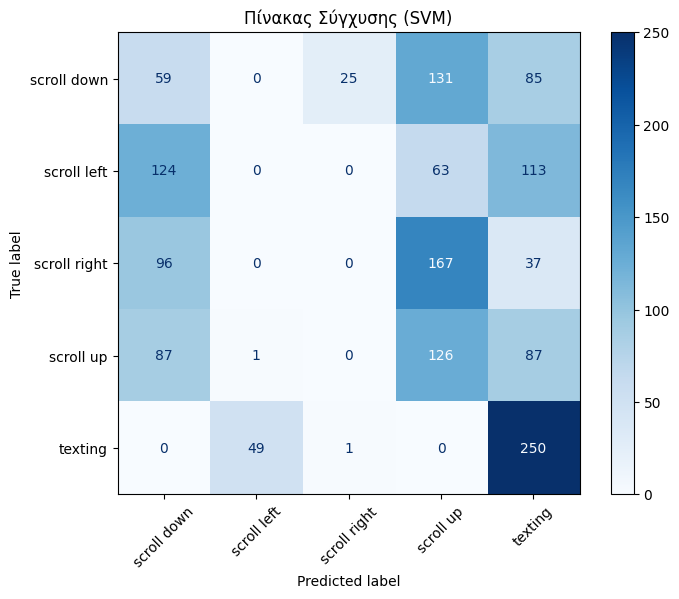

In [8]:
print("\n Εκπαίδευση Απλού Μοντέλου SVM ")
clf = SVC(kernel='linear', random_state=42)
clf.fit(X_train_scaled, y_train)

y_pred = clf.predict(X_test_scaled)
print(classification_report(y_test, y_pred))

# Πίνακας Σύγχυσης
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=clf.classes_)
fig, ax = plt.subplots(figsize=(8, 6))
disp.plot(cmap=plt.cm.Blues, ax=ax)
plt.title("Πίνακας Σύγχυσης (SVM)")
plt.xticks(rotation=45)
plt.show()


Βελτιστοποίηση με GridSearchCV 
Fitting 3 folds for each of 6 candidates, totalling 18 fits
Καλύτερες παράμετροι: {'C': 10, 'kernel': 'rbf'}

 Τελική Αναφορά Βελτιστοποιημένου Μοντέλου 
              precision    recall  f1-score   support

 scroll down       0.00      0.00      0.00       300
 scroll left       0.00      0.00      0.00       300
scroll right       0.00      0.00      0.00       300
   scroll up       0.02      0.00      0.01       301
     texting       0.21      0.99      0.35       300

    accuracy                           0.20      1501
   macro avg       0.05      0.20      0.07      1501
weighted avg       0.05      0.20      0.07      1501



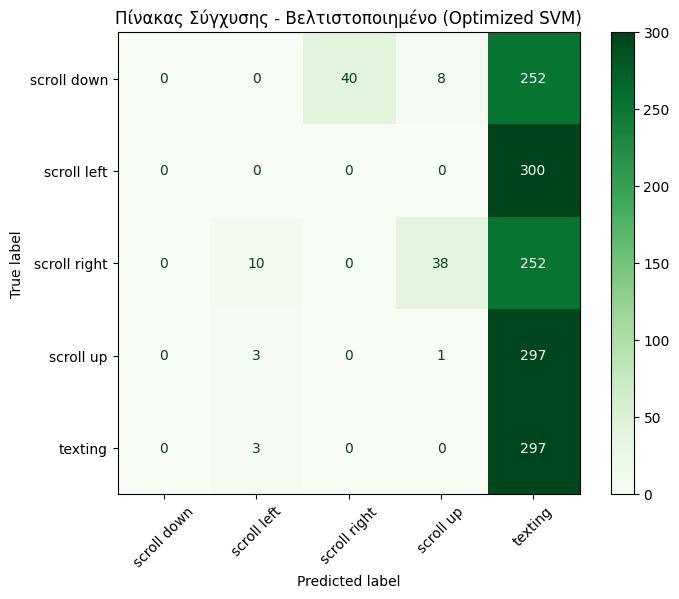

 
 Εκπαίδευση με Random Forest 
Fitting 3 folds for each of 6 candidates, totalling 18 fits
Καλύτερες παράμετροι (Random Forest): {'max_depth': None, 'n_estimators': 200, 'random_state': 42}

 Αναφορά Μοντέλου Random Forest 
              precision    recall  f1-score   support

 scroll down       0.00      0.00      0.00       300
 scroll left       0.00      0.00      0.00       300
scroll right       0.00      0.00      0.00       300
   scroll up       0.19      0.01      0.02       301
     texting       0.21      1.00      0.34       300

    accuracy                           0.20      1501
   macro avg       0.08      0.20      0.07      1501
weighted avg       0.08      0.20      0.07      1501



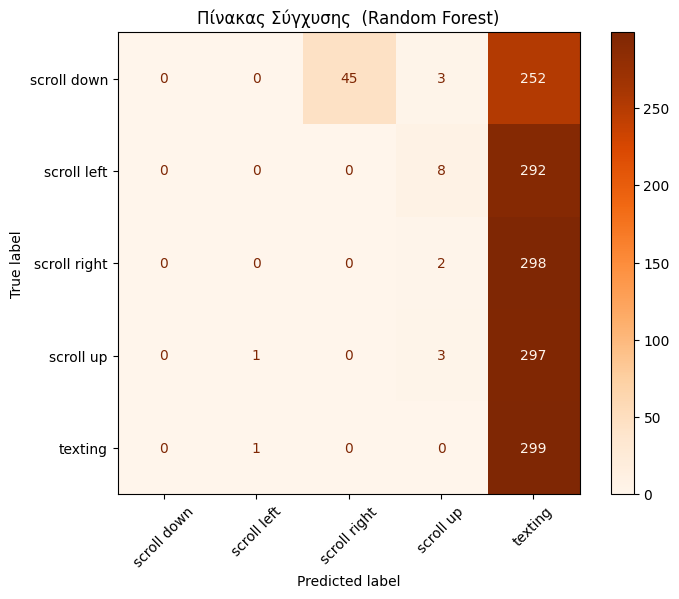

In [9]:
print("\nΒελτιστοποίηση με GridSearchCV ")
param_grid = {
    'C': [0.1, 1, 10],
    'kernel': ['linear', 'rbf']
}

grid_search = GridSearchCV(SVC(random_state=42), param_grid, cv=3, scoring='accuracy', n_jobs=-1, verbose=1)
grid_search.fit(X_train_scaled, y_train)

print(f"Καλύτερες παράμετροι: {grid_search.best_params_}")
best_clf = grid_search.best_estimator_

y_pred_opt = best_clf.predict(X_test_scaled)
print("\n Τελική Αναφορά Βελτιστοποιημένου Μοντέλου ")
print(classification_report(y_test, y_pred_opt, zero_division=0))

cm_opt = confusion_matrix(y_test, y_pred_opt)
disp_opt = ConfusionMatrixDisplay(confusion_matrix=cm_opt, display_labels=best_clf.classes_)
fig, ax = plt.subplots(figsize=(8, 6))
disp_opt.plot(cmap=plt.cm.Greens, ax=ax)
plt.title("Πίνακας Σύγχυσης - Βελτιστοποιημένο (Optimized SVM)")
plt.xticks(rotation=45)
plt.show()

#Random Forest Classifier
from sklearn.ensemble import RandomForestClassifier
print(" \n Εκπαίδευση με Random Forest ")


# Ορίζουμε τις παραμέτρους για το Random Forest
param_grid_rf = {
    'n_estimators': [100, 200],
    'max_depth': [10, 20, None],
    'random_state': [42]
}

# Βελτιστοποίηση με GridSearchCV
grid_search_rf = GridSearchCV(RandomForestClassifier(), param_grid_rf, cv=3, scoring='accuracy', n_jobs=-1, verbose=1)
grid_search_rf.fit(X_train_scaled, y_train)

print(f"Καλύτερες παράμετροι (Random Forest): {grid_search_rf.best_params_}")
best_rf_clf = grid_search_rf.best_estimator_

# Πρόβλεψη και Αξιολόγηση
y_pred_rf = best_rf_clf.predict(X_test_scaled)
print("\n Αναφορά Μοντέλου Random Forest ")
print(classification_report(y_test, y_pred_rf, zero_division=0))

# Πίνακας Σύγχυσης 
cm_rf = confusion_matrix(y_test, y_pred_rf)
disp_rf = ConfusionMatrixDisplay(confusion_matrix=cm_rf, display_labels=best_rf_clf.classes_)
fig, ax = plt.subplots(figsize=(8, 6))
disp_rf.plot(cmap=plt.cm.Oranges, ax=ax)
plt.title("Πίνακας Σύγχυσης  (Random Forest)")
plt.xticks(rotation=45)
plt.show()

Mixed Users - Raw Data 

Εκπαίδευση με SVM (Mixed Users)
Fitting 3 folds for each of 6 candidates, totalling 18 fits
Καλύτερες παράμετροι: {'C': 10, 'kernel': 'rbf'}

 Τελική Αναφορά Βελτιστοποιημένου Μοντέλου (Mixed Users - SVM)
              precision    recall  f1-score   support

 scroll down       0.85      0.85      0.85       190
 scroll left       0.83      0.90      0.87       187
scroll right       0.85      0.89      0.87       184
   scroll up       0.89      0.78      0.83       158
     texting       0.93      0.90      0.92       182

    accuracy                           0.87       901
   macro avg       0.87      0.86      0.87       901
weighted avg       0.87      0.87      0.87       901



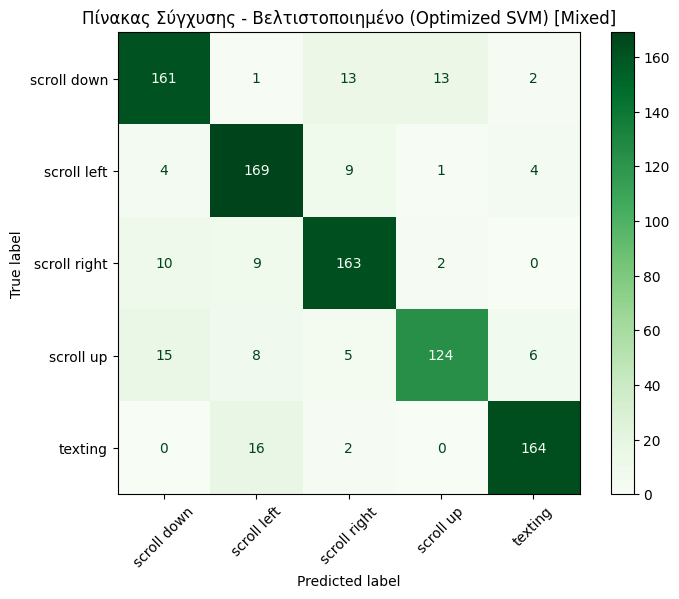

 
 Εκπαίδευση με Random Forest (Mixed Users) 
Fitting 3 folds for each of 6 candidates, totalling 18 fits
Καλύτερες παράμετροι (Random Forest): {'max_depth': None, 'n_estimators': 200, 'random_state': 42}

 Αναφορά Μοντέλου Random Forest (Mixed Users) 
              precision    recall  f1-score   support

 scroll down       0.93      0.95      0.94       190
 scroll left       0.92      0.91      0.92       187
scroll right       0.93      0.95      0.94       184
   scroll up       0.95      0.92      0.93       158
     texting       0.97      0.95      0.96       182

    accuracy                           0.94       901
   macro avg       0.94      0.94      0.94       901
weighted avg       0.94      0.94      0.94       901



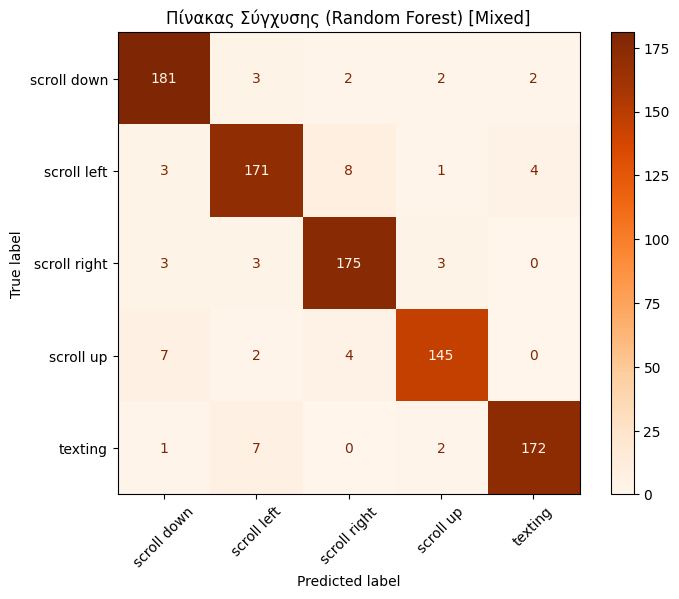

In [10]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
print("Mixed Users - Raw Data ")

# Ανακατεύουμε όλα τα δεδομένα (Mitsos, Mpakas, Alexis)
X_train_mix, X_test_mix, y_train_mix, y_test_mix = train_test_split(
    X, y, test_size=0.20, shuffle=True, random_state=42
)

# Κανονικοποίηση 
scaler_mix = StandardScaler()
X_train_mix_scaled = scaler_mix.fit_transform(X_train_mix)
X_test_mix_scaled = scaler_mix.transform(X_test_mix)

# SVM
print("\nΕκπαίδευση με SVM (Mixed Users)")
param_grid = {
    'C': [0.1, 1, 10],
    'kernel': ['linear', 'rbf']
}

grid_search = GridSearchCV(SVC(random_state=42), param_grid, cv=3, scoring='accuracy', n_jobs=-1, verbose=1)
grid_search.fit(X_train_mix_scaled, y_train_mix)

print(f"Καλύτερες παράμετροι: {grid_search.best_params_}")
best_clf = grid_search.best_estimator_

y_pred_opt = best_clf.predict(X_test_mix_scaled)
print("\n Τελική Αναφορά Βελτιστοποιημένου Μοντέλου (Mixed Users - SVM)")
print(classification_report(y_test_mix, y_pred_opt, zero_division=0))

cm_opt = confusion_matrix(y_test_mix, y_pred_opt)
disp_opt = ConfusionMatrixDisplay(confusion_matrix=cm_opt, display_labels=best_clf.classes_)
fig, ax = plt.subplots(figsize=(8, 6))
disp_opt.plot(cmap=plt.cm.Greens, ax=ax)
plt.title("Πίνακας Σύγχυσης - Βελτιστοποιημένο (Optimized SVM) [Mixed]")
plt.xticks(rotation=45)
plt.show()


#Random Forest
print(" \n Εκπαίδευση με Random Forest (Mixed Users) ")

param_grid_rf = {
    'n_estimators': [100, 200],
    'max_depth': [10, 20, None],
    'random_state': [42]
}

# Βελτιστοποίηση με GridSearchCV
grid_search_rf = GridSearchCV(RandomForestClassifier(), param_grid_rf, cv=3, scoring='accuracy', n_jobs=-1, verbose=1)
grid_search_rf.fit(X_train_mix_scaled, y_train_mix)

print(f"Καλύτερες παράμετροι (Random Forest): {grid_search_rf.best_params_}")
best_rf_clf = grid_search_rf.best_estimator_

# Πρόβλεψη και Αξιολόγηση
y_pred_rf = best_rf_clf.predict(X_test_mix_scaled)
print("\n Αναφορά Μοντέλου Random Forest (Mixed Users) ")
print(classification_report(y_test_mix, y_pred_rf, zero_division=0))

# Πίνακας Σύγχυσης 
cm_rf = confusion_matrix(y_test_mix, y_pred_rf)
disp_rf = ConfusionMatrixDisplay(confusion_matrix=cm_rf, display_labels=best_rf_clf.classes_)
fig, ax = plt.subplots(figsize=(8, 6))
disp_rf.plot(cmap=plt.cm.Oranges, ax=ax)
plt.title("Πίνακας Σύγχυσης (Random Forest) [Mixed]")
plt.xticks(rotation=45)
plt.show()